<a href="https://colab.research.google.com/github/FatmaRaafat/A-Brain-Tumor-MRI-Classification-Using-Custom-CNN-with-Integrated-Gradients-Interpretability/blob/main/Brain_Tumor_MRI_Classifier_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***`A 94% Accuracy Brain Tumor Classification from MRI Using Custom CNN with Integrated Gradients Interpretability`***

This project presents a brain tumor MRI classification system that identifies four classes: glioma, meningioma, no tumor, and pituitary tumor. The goal of the project is to demonstrate how deep learning can be used to support medical image classification by automatically learning patterns from MRI scans. In addition, the project includes an explainability component using Integrated Gradients, which highlights the regions of the MRI image that most influenced the model’s prediction. This makes the system more transparent and easier to interpret, especially in a medical context where understanding why a prediction was made is just as important as the prediction itself.

# 0. Imports

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
# Why these specific libraries:
#   - cv2 (OpenCV): industry-standard for image loading and resizing. Faster
#     than PIL for batch processing and gives us explicit control over color
#     space conversion (grayscale → BGR).
#   - sklearn: provides train_test_split with stratify support (ensures each
#     split has the same class distribution as the full dataset) and
#     classification_report for per-class precision/recall/F1.
#   - tensorflow.keras: high-level API for model building, training, and
#     inference. Used over raw TensorFlow for cleaner model definition.
#   - ImageDataGenerator: Keras utility for on-the-fly augmentation. Used
#     instead of pre-augmenting the dataset to save disk space and memory.
#   - to_categorical: converts integer class labels [0,1,2,3] to one-hot
#     vectors [[1,0,0,0], [0,1,0,0], ...] required by categorical_crossentropy.


# 1. Config

In [8]:
BASE_DATA_DIR = '/content/drive/MyDrive/Personal Projects/Brain Tumor Dataset/brain-tumor-mri-dataset'
MODEL_SAVE    = '/content/drive/MyDrive/Personal Projects/Brain Tumor Dataset/best_custom_cnn.keras'
CLASS_NAMES   = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES   = len(CLASS_NAMES)

# 128×128 is chosen over the standard 224×224 for two reasons:
# 1. Memory: 128×128 uses 4× less GPU memory than 224×224, enabling stable
#    training on Colab's free tier without mid-epoch interruptions.
# 2. Sufficiency: Brain tumor features (mass location, boundary, shape) are
#    clearly visible at 128×128 resolution for all four classes.

IMG_SIZE      = (128, 128)

# Batch size of 32 is a standard default that balances:
# - Gradient quality (larger batches = more stable gradient estimates)
# - Memory usage (larger batches = more GPU memory needed)
# - Training speed (larger batches = fewer steps per epoch)

BATCH_SIZE    = 32

# Maximum epochs. EarlyStopping will terminate training early if
# val_accuracy stops improving, so this is a ceiling, not a target.

EPOCHS        = 40


# 2. Preprocessing Function

In [9]:
def preprocess_brain_mri(image_path, target_size=IMG_SIZE):
    """
    Loads a brain MRI image, resizes it, and converts it to 3-channel format.

    Args:
        image_path  : str — full path to the image file
        target_size : tuple — (width, height) to resize to; default (128, 128)

    Returns:
        np.ndarray of shape (128, 128, 3), dtype uint8, pixel values in [0, 255]
        Returns None if the image cannot be read (corrupted or missing file).
    """
    # Read as grayscale — MRI scans contain no color information.
    # Even if the file is saved as RGB (which some in this dataset are),
    # reading as grayscale collapses the channels to luminance, which is
    # the only meaningful signal in an MRI scan.

    img_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img_gray is None:
        # File could not be read — skip it silently
        return None

    # Resize to the target size using INTER_AREA interpolation.
    # INTER_AREA is the best choice for downsampling: it averages pixel values
    # in each output cell's area rather than sampling at discrete points,
    # producing a cleaner result than INTER_LINEAR or INTER_NEAREST when
    # reducing image size.

    resized = cv2.resize(img_gray, target_size, interpolation=cv2.INTER_AREA)

    # Convert single-channel grayscale to 3-channel BGR by duplicating the
    # grayscale channel three times. The model expects 3 channels because
    # Conv2D layers are designed for this format. All three channels will
    # contain identical values — no color information is added.

    rgb_img = cv2.cvtColor(resized, cv2.COLOR_GRAY2BGR)

    return rgb_img # uint8, range [0, 255] — do NOT divide here

The reason for converting grayscale images into three channels is to keep the input compatible with standard convolutional network pipelines that expect RGB-style input, while still preserving the original image content.

# 3. Build dataset arrays

In [10]:
# We load all images into memory as NumPy arrays (X_full, y_full).
# Total size: 7153 images × 128×128×3 bytes = ~352 MB — fits comfortably
# in Colab's ~12 GB RAM allocation.
#
# IMPORTANT: os.listdir() returns files in arbitrary filesystem order.
# This is fine for training (randomness doesn't matter when we shuffle),
# but if you need to reproduce the exact same train/test split later
# (e.g., for standalone IG analysis), you MUST save X_test.npy and y_test.npy
# after training. Do NOT rely on rebuilding the split
# from os.listdir() in a new session — the order will differ.

print("\nLoading dataset...")
X_list, y_list = [], []

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_path  = os.path.join(BASE_DATA_DIR, class_name)
    image_files = [f for f in os.listdir(class_path)
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    print(f"  {class_name}: {len(image_files)} images")

    for i, fname in enumerate(image_files):
        img = preprocess_brain_mri(os.path.join(class_path, fname))
        if img is not None:
            X_list.append(img)
            y_list.append(class_idx) # integer label: 0, 1, 2, or 3

# Convert to NumPy arrays. dtype=uint8 keeps memory usage minimal:
# float32 would use 4× more RAM for the same data.

X_full = np.array(X_list, dtype=np.uint8)
y_full = np.array(y_list)
print(f"\nDataset: {X_full.shape} | Labels: {y_full.shape}")


Loading dataset...
  glioma: 1621 images
  meningioma: 1775 images
  notumor: 2000 images
  pituitary: 1757 images

Dataset: (7153, 128, 128, 3) | Labels: (7153,)


# 4. Train / Val / Test split

In [11]:
#WHY STRATIFY?
# Without stratify, random splits might put 80% of pituitary images in train
# and only 10% in test — giving misleading per-class metrics. Stratify ensures
# each class appears in each split at the same proportion as the full dataset.

# random_state=42 makes the split reproducible — running the code again
# produces the exact same splits, as long as the input array order is
# also the same (hence the importance of saving X_test.npy).


y_one_hot = to_categorical(y_full, num_classes=NUM_CLASSES)
# y_one_hot shape: (7153, 4)
# e.g., class 2 (notumor) becomes [0, 0, 1, 0]

# Step 1: 70% train, 30% temp (will be split into val and test)
X_train, X_val_test, y_train, y_val_test = train_test_split(
    X_full, y_one_hot,
    test_size=0.30,
    random_state=42,
    stratify=y_full
)


X_val, X_test, y_val, y_test = train_test_split(
    X_val_test, y_val_test,
    test_size=0.50,
    random_state=42,
    stratify=np.argmax(y_val_test, axis=1) # convert back to int for stratify
)
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")


Train: 5007 | Val: 1073 | Test: 1073


70% Train, 15% Validation, 15% Test

# 5. Data generators (Augmentation)

In [12]:
# ImageDataGenerator applies random transformations to training images
# on-the-fly during training. This artificially multiplies the effective
# training set size and forces the model to be invariant to these
# transformations — a key technique for preventing overfitting.
#
# AUGMENTATIONS CHOSEN AND WHY:
#   rotation_range=20     : MRI scans may be slightly tilted; 20° is realistic
#   width/height_shift=0.15: Slight translations simulate scan positioning variation
#   zoom_range=0.15       : Slight zoom simulates different imaging distances
#   horizontal_flip=True  : Brain hemispheres are roughly symmetric; flipping
#                           is medically valid for this dataset
#   fill_mode='nearest'   : Fills empty borders after transformation by repeating
#                           edge pixels — avoids the black border artifact that
#                           'constant' (zero fill) would introduce
#
# AUGMENTATIONS NOT USED AND WHY:
#   vertical_flip=False   : Upside-down brains don't appear in clinical scans
#   shear_range=0         : Shear distortion is not a realistic MRI artifact
#   brightness_range      : Not used because Rescaling(1/255) inside the model
#                           already normalizes brightness
#
# CRITICAL: NO rescale parameter here.
# The model's first layer Rescaling(1/255) handles normalization internally.
# Setting rescale=1./255 here AND having Rescaling inside the model would
# divide pixel values by 255 twice, producing values in [0, 0.004] —
# which destroyed training in the EfficientNetB0 experiments (val_loss → 945).

def make_generators():
    """
    Returns:
        tgen : training generator with augmentation
        vgen : validation generator without augmentation
    """
    train_datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.15,
        height_shift_range=0.15,
        zoom_range=0.15,
        horizontal_flip=True,
        fill_mode='nearest'
        # No rescale — model handles normalization internally
    )

    # Validation data: no augmentation. We want to evaluate on realistic,
    # unmodified images so the validation metric is comparable to real-world use.
    val_datagen = ImageDataGenerator()

    tgen = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
    vgen = val_datagen.flow(X_val,   y_val,   batch_size=BATCH_SIZE, shuffle=False)

    # shuffle=False for validation: order doesn't matter for evaluation,
    # and not shuffling makes debugging easier.

    return tgen, vgen

To improve generalization, the training data was augmented using random rotations, width shifts, height shifts, zoom, and horizontal flips. These transformations help the model learn more robust patterns instead of memorizing exact image positions or orientations.

# 6. Build Model

In [13]:
# Design decisions explained:
#
# Block structure: Conv → BatchNorm → ReLU → Conv → BatchNorm → ReLU → MaxPool
#   BatchNorm after every Conv stabilizes training and acts as mild regularizer.
#   Two convs per block before pooling lets the model learn richer features
#   before losing spatial resolution.
#
# Filters: 32 → 64 → 128 → 256
#   Classic doubling pattern. Early layers learn edges and textures (need few
#   filters). Deep layers learn complex shapes like tumor boundaries (need more).
#
# Kernel size: 3×3 throughout
#   The standard for CNNs — two 3×3 convs have the same receptive field as one
#   5×5 but with fewer parameters and more non-linearity.
#
# GlobalAveragePooling instead of Flatten:
#   Flatten after 4 pooling blocks on 128×128 images = enormous vector.
#   GAP collapses each feature map to a single number — far fewer parameters,
#   less overfitting, and it's what makes Integrated Gradients work cleanly.
#
# L2 regularization on dense layers:
#   Penalizes large weights to prevent the head from memorizing training data.

import tensorflow.keras.regularizers as regularizers

def build_custom_cnn(input_shape=(128, 128, 3), num_classes=4):

    """
    Builds a custom 4-block CNN for brain tumor classification.

    Architecture philosophy:
    - 4 convolutional blocks with doubling filter counts (32→64→128→256)
    - Two Conv2D layers per block before MaxPooling
    - BatchNormalization after every Conv for training stability
    - Dropout after each block with increasing rates (0.25→0.25→0.30→0.30)
    - GlobalAveragePooling head (not Flatten) for regularization + IG compatibility
    - L2 regularization on the dense layer

    Args:
        input_shape : tuple — (H, W, C), default (128, 128, 3)
        num_classes : int — number of output classes, default 4

    Returns:
        tf.keras.Model
    """

    inputs = tf.keras.Input(shape=input_shape)

    # Normalization — handles the [0,255] → [0,1] conversion inside the model
    x = layers.Rescaling(1./255)(inputs)

    # ── Block 1: 32 filters ──────────────────────────────
      # First block uses 32 filters — sufficient for detecting low-level features
      # (edges, gradients, intensity transitions) that are present across the
      # full 128×128 spatial resolution.

    x = layers.Conv2D(32, (3, 3), padding='same')(x)
      # padding='same' preserves spatial dimensions after convolution,
      # so MaxPooling is the only operation that reduces resolution.

    x = layers.BatchNormalization()(x)
      # BN normalizes across the batch dimension before activation.
      # This stabilizes the gradient flow and acts as a mild regularizer.

    x = layers.Activation('relu')(x)
      # ReLU is the standard choice: f(x) = max(0, x). Cheap to compute,
      # doesn't saturate for positive values, sparse (many zeros = efficient).

    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)          # 128 → 64
      # MaxPooling takes the maximum value in each 2×2 window. This:
      # 1. Halves spatial dimensions (saves memory and computation)
      # 2. Provides translation invariance (small shifts don't change output)
      # 3. Forces the network to learn increasingly abstract representations

    x = layers.Dropout(0.25)(x)
    # Dropout randomly zeroes 25% of activations during training.
    # Forces the network to learn redundant representations — no single
    # neuron can become critical, which prevents overfitting.

    # ── Block 2: 64 filters ──────────────────────────────
      # Filter count doubles as spatial dimensions halve, keeping total
      # information capacity approximately constant through the network.
      # At 64×64 resolution, the model learns mid-level features: textures,
      # local patterns, simple shape components.

    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)          # 64 → 32
    x = layers.Dropout(0.25)(x)

    # ── Block 3: 128 filters ─────────────────────────────
      # At 32×32 resolution, the model learns higher-level features: shapes,
      # boundaries, region statistics. 128 filters needed to represent the
      # growing diversity of patterns the model must distinguish.

    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)          # 32 → 16
    x = layers.Dropout(0.30)(x)

    # ── Block 4: 256 filters ─────────────────────────────
      # At 16×16 resolution, the model sees highly abstract features specific
      # to each class: the diffuse infiltrating pattern of glioma, the
      # well-circumscribed boundary of meningioma, the small rounded mass
      # of pituitary tumors. 256 filters provides enough capacity for this.

    x = layers.Conv2D(256, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)          # 16 → 8
    x = layers.Dropout(0.30)(x)

    # ── Head ─────────────────────────────────────────────
      # After 4 MaxPool layers: (batch, 8, 8, 256) feature maps

    x = layers.GlobalAveragePooling2D()(x)

      # GAP computes the mean of each 8×8 feature map → (batch, 256).
      # WHY NOT FLATTEN?
      # Flatten would give 8×8×256 = 16,384 features → dense layer with
      # 16,384 × 256 = 4.2M weights. That's more parameters than the entire
      # convolutional backbone, making the head the dominant overfitting source.
      # GAP produces just 256 features and only 256×256 = 65k dense weights.
      # Crucially, GAP also preserves spatial correspondence: each output value
      # corresponds to the average activation of one feature map across the
      # entire spatial grid. This spatial correspondence is what allows
      # Integrated Gradients to produce meaningful pixel-level attribution maps.

    x = layers.Dense(256,
                     activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
      # L2 regularization adds λ×Σ(w²) to the loss, penalizing large weights.
      # λ=1e-4 is a mild penalty: strong enough to prevent any single hidden
      # unit from becoming dominant, weak enough not to underfit.

    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

      # 50% dropout on the dense layer — the highest rate in the network.
      # The dense layer has the most capacity for memorization (it sees the
      # full 256-dim feature vector for every image), so it needs the strongest
      # regularization pressure.


    outputs = layers.Dense(num_classes, activation='softmax')(x)

      # Softmax output: produces a probability distribution over 4 classes.
      # All outputs sum to 1.0, and each is in [0, 1].
      # Used instead of sigmoid because classes are mutually exclusive:
      # an MRI shows exactly one condition, not a combination.


    return tf.keras.Model(inputs, outputs)


model = build_custom_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=NUM_CLASSES)
model.summary()

# Quick parameter count check
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"\nTotal trainable parameters: {trainable_params:,}")

# ~1.24M — roughly 3.5× fewer than EfficientNetB0 (4.4M)
print("(EfficientNetB0 had 4,379,559 — this model is intentionally lighter)")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,243,940 (4.75 MB)

 Trainable params: 1,241,508 (4.74 MB)

 Non-trainable params: 2,432 (9.50 KB)


Total trainable parameters: 1,241,508
(EfficientNetB0 had 4,379,559 — this model is intentionally lighter)


##Model Explanation
The model starts with an MRI image of size 128 by 128 with 3 channels, then rescales the pixel values so the network works with normalized input rather than raw image values. After that, it passes through four convolution blocks, and each block learns progressively more complex features: the first blocks focus on simple edges and textures, while the deeper blocks learn tumor-related shapes and patterns.

Each block uses two convolution layers before pooling, which helps the network extract richer features before the spatial information is reduced. Batch normalization is used after each convolution to stabilize training, ReLU adds non-linearity, max pooling reduces the image size step by step, and dropout helps prevent overfitting.

At the end, GlobalAveragePooling2D compresses each feature map into a single value, which keeps the model smaller and reduces the risk of memorizing the training data. Then the dense layer with L2 regularization learns the final decision boundary, and the softmax output gives probabilities for the four classes.

# 7. Compile

In [14]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),

      # Adam (Adaptive Moment Estimation) adapts the learning rate per parameter
      # based on first and second moment estimates of gradients. It converges
      # faster than vanilla SGD and is less sensitive to hyperparameter choices.
      # lr=1e-3 is Adam's standard default starting point.

    loss='categorical_crossentropy',

      # Used when labels are one-hot encoded (y shape: [N, 4]).
      # Measures the difference between predicted probability distribution
      # and the true one-hot distribution. Use 'sparse_categorical_crossentropy'
      # if labels are integers instead.


    metrics=['accuracy']

      # Accuracy is easy to interpret but insufficient alone for imbalanced data.
      # Full precision/recall/F1 are computed separately in Section 10.
)

# 8. Callbacks

In [15]:
# Callbacks are functions called at the end of each epoch that allow
# automated control of the training process.

callbacks = [
    ModelCheckpoint(
        MODEL_SAVE,
        monitor='val_accuracy', # Watch validation accuracy, not training accuracy.
                                # Training accuracy always increases; val_accuracy
                                # is the honest signal of generalization.
        save_best_only=True,    # Only overwrite the saved file when val_accuracy improves.
                                # Ensures the saved model is always the best seen so far,
                                # not the most recent (which may have overfit).
        verbose=1               #progress bar
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,               # Stop if val_accuracy doesn't improve for 10 consecutive epochs.
                                   # Patience=10 is generous — custom CNNs can plateau temporarily
                                   # and then improve (as seen around epoch 30 in this training run).
                                   # Shorter patience risks stopping too early.

        restore_best_weights=True, # After stopping, restores the weights from the best epoch
                                   # rather than the final epoch (which may have overfit).
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',        # Watch loss (more granular than accuracy) for plateaus.
        factor=0.5,                # Halve the learning rate when triggered.
        patience=4,                # Wait 4 epochs of no improvement before reducing.
        min_lr=1e-7,               # Floor — never reduce below this to avoid numerical issues.
        verbose=1
    ),
    # ReduceLROnPlateau helps escape loss plateaus by taking smaller steps.
    # When the model's gradient updates become too large to find a better
    # minimum, reducing the LR lets it take more precise steps.
]

### Training Strategy
Training is controlled using three callbacks: `ModelCheckpoint`, `EarlyStopping`, and `ReduceLROnPlateau`. `ModelCheckpoint` saves the best-performing model on the validation set, `EarlyStopping` prevents unnecessary overtraining, and `ReduceLROnPlateau` lowers the learning rate when validation loss stops improving. This combination makes the training process more stable and helps the model recover from plateaus instead of continuing with an overly large learning rate.

# 9. Train

In [16]:
print("\n── Training custom CNN ──")
train_gen, val_gen = make_generators()

history = model.fit(
    train_gen,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    # Number of batches per epoch. Using // ensures we process complete batches
    # only. Equivalently: 5007 // 32 = 156 steps per epoch.
    # Note: this means ~1% of training data is skipped each epoch (the partial
    # last batch). This is standard practice.

    epochs=EPOCHS,
    # Maximum epochs. EarlyStopping will likely terminate before this.

    validation_data=val_gen,
    validation_steps=None,
    # None means: run the full validation set every epoch, regardless of batch count.
    # Previously using len(X_val)//BATCH_SIZE silently dropped the last partial
    # batch (17 samples), giving a slightly biased val_accuracy reading.

    callbacks=callbacks
)

print(f"\nBest val_accuracy: {max(history.history['val_accuracy']):.4f}")



── Training custom CNN ──
Epoch 1/40
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.5665 - loss: 1.1340
Epoch 1: val_accuracy improved from None to 0.24604, saving model to /content/drive/MyDrive/Personal Projects/Brain Tumor Dataset/best_custom_cnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Personal Projects/Brain Tumor Dataset/best_custom_cnn.keras
156/156 ━━━━━━━━━━━━━━━━━━━━ 68s 280ms/step - accuracy: 0.6316 - loss: 0.9845 - val_accuracy: 0.2460 - val_loss: 2.3389 - learning_rate: 0.0010
Epoch 2/40
  1/156 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - accuracy: 0.7500 - loss: 0.6699

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.24604
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7500 - loss: 0.6699 - val_accuracy: 0.2460 - val_loss: 2.4905 - learning_rate: 0.0010
Epoch 3/40
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.6949 - loss: 0.8093
Epoch 3: val_accuracy improved from 0.24604 to 0.25349, saving model to /content/drive/MyDrive/Personal Projects/Brain Tumor Dataset/best_custom_cnn.keras

Epoch 3: finished saving model to /content/drive/MyDrive/Personal Projects/Brain Tumor Dataset/best_custom_cnn.keras
156/156 ━━━━━━━━━━━━━━━━━━━━ 24s 151ms/step - accuracy: 0.7160 - loss: 0.7551 - val_accuracy: 0.2535 - val_loss: 1.6763 - learning_rate: 0.0010
Epoch 4/40
  1/156 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.7812 - loss: 0.6110
Epoch 4: val_accuracy improved from 0.25349 to 0.25629, saving model to /content/drive/MyDrive/Personal Projects/Brain Tumor Dataset/best_custom_cnn.keras

Epoch 4: finished saving model to /content/drive/MyDrive/Pe

# 10. Test Set Evaluation

In [17]:
# The test set is used ONLY here — the model has never seen these images
# during training or hyperparameter tuning.

print("\n── Test set evaluation ──")
test_gen      = ImageDataGenerator().flow(X_test, y_test, batch_size=BATCH_SIZE, shuffle=False)
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")

# Generate predictions for full classification report

pred_gen = ImageDataGenerator().flow(X_test, batch_size=BATCH_SIZE, shuffle=False)
# Note: pass only X_test here (no labels) because we're getting raw predictions

y_pred   = np.argmax(model.predict(pred_gen), axis=1)
y_true   = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
  # Precision: of all predictions for class X, what fraction were correct?
  # Recall: of all true class X samples, what fraction did we catch?
  # F1: harmonic mean of precision and recall — good single summary metric
  # Support: number of true samples per class in the test set



── Test set evaluation ──
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9404 - loss: 0.1915
Test accuracy: 0.9404 | Test loss: 0.1915
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step

Classification Report:
              precision    recall  f1-score   support

      glioma       0.95      0.95      0.95       243
  meningioma       0.93      0.86      0.89       267
     notumor       0.95      0.95      0.95       300
   pituitary       0.93      0.99      0.96       263

    accuracy                           0.94      1073
   macro avg       0.94      0.94      0.94      1073
weighted avg       0.94      0.94      0.94      1073



In [18]:
import numpy as np

# CRITICAL: Save X_test and y_test immediately after training.
# os.listdir() returns files in arbitrary order — if you rebuild the dataset
# in a new session without sorting, the split will be different and y_test
# will not correspond to X_test. This causes the accuracy to appear as ~25%
# (random chance) when in reality the model is correct but the labels are wrong.

np.save('/content/drive/MyDrive/Personal Projects/Brain Tumor Dataset/X_test.npy', X_test)
np.save('/content/drive/MyDrive/Personal Projects/Brain Tumor Dataset/y_test.npy', y_test)
print("Test set saved ✓")

Test set saved ✓


# 11. Confusion Matrix

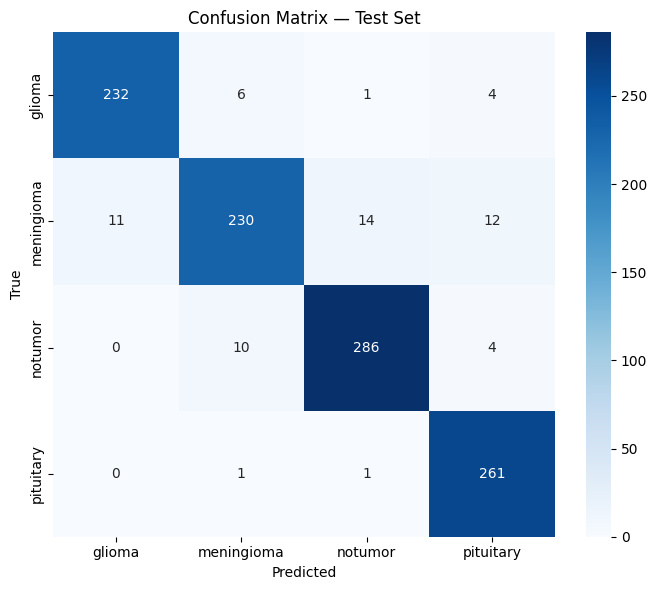

In [19]:
plt.figure(figsize=(7, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout(); plt.show()

# 12. Training Curve

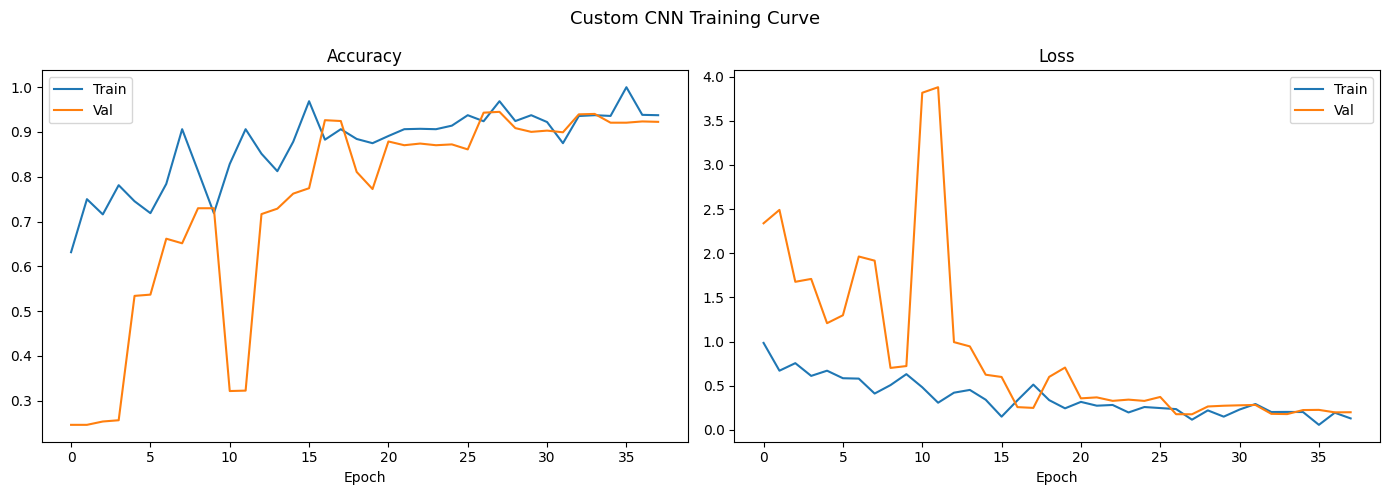


Model saved to: /content/drive/MyDrive/Personal Projects/Brain Tumor Dataset/best_custom_cnn.keras


In [20]:
# The training curve shows accuracy and loss over epochs for both train and val.
# What to look for:
# - Train acc >> Val acc: overfitting
# - Both low: underfitting
# - Val acc ≈ Train acc and both high: good generalization
#
# NOTE ON FLUCTUATIONS: Colab's free GPU occasionally interrupts training
# mid-epoch to reclaim resources. When this happens, Keras evaluates the
# validation set after an incomplete epoch, producing noisy val_accuracy readings.
# The self._interrupted_warning() messages in training logs confirm this.
# The overall trend (25% → 94%) is the meaningful signal, not individual spikes.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.suptitle('Custom CNN Training Curve', fontsize=13)
plt.tight_layout(); plt.show()

print(f"\nModel saved to: {MODEL_SAVE}")


# 13. Integrated gradients

In [21]:
import io, cv2, base64, threading
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf

Standalone cell, no need to retrain the model, it's already trained

In [22]:
# ─ Standalone loader — run this INSTEAD of the full notebook ──
import os, cv2, numpy as np, tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Config (must match what you trained with)
BASE_DATA_DIR = '/content/drive/MyDrive/Personal Projects/Brain Tumor Dataset/brain-tumor-mri-dataset'
MODEL_SAVE    = '/content/drive/MyDrive/Personal Projects/Brain Tumor Dataset/best_custom_cnn.keras'
CLASS_NAMES   = ['glioma', 'meningioma', 'notumor', 'pituitary']
IMG_SIZE      = (128, 128)

# Load model
model = tf.keras.models.load_model(MODEL_SAVE)
print("Model loaded ✓")

# Rebuild X_test / y_test with the exact same split
# Load saved test set — guaranteed to match training
X_test = np.load('/content/drive/MyDrive/Personal Projects/Brain Tumor Dataset/X_test.npy')
y_test = np.load('/content/drive/MyDrive/Personal Projects/Brain Tumor Dataset/y_test.npy')
print(f"Test set loaded: {X_test.shape} ✓")

# Sanity check — should be ~0.94
from tensorflow.keras.preprocessing.image import ImageDataGenerator
test_gen = ImageDataGenerator().flow(X_test, y_test, batch_size=32, shuffle=False)
_, test_acc = model.evaluate(test_gen, verbose=0)
print(f"Test accuracy: {test_acc:.4f}  ← must be ~0.94 before running IG")

print(f"Test set rebuilt: {X_test.shape}  ✓")

Model loaded ✓
Test set loaded: (1073, 128, 128, 3) ✓
Test accuracy: 0.9404  ← must be ~0.94 before running IG
Test set rebuilt: (1073, 128, 128, 3)  ✓


## A. integrated Gradients

In [34]:
def compute_integrated_gradients(model, image, target_class, steps=50):
    """
    Computes Integrated Gradients attribution map for a single image.

    Theory:
        Standard gradients suffer from saturation: once a neuron is strongly
        activated, its gradient ≈ 0 even for obviously important inputs.
        IG fixes this by integrating gradients along the path from a black
        baseline image to the actual input image.

        Formula: IG(x) = (x − x') × ∫₀¹ ∂F(x' + α(x−x')) / ∂x dα

        Where x' is the black baseline (all zeros), F is softmax output
        for the target class, and α ∈ [0, 1] is the interpolation factor.

    Implementation details:
        - Uses softmax probabilities (not raw logits) for gradient computation.
          Softmax outputs are bounded [0,1] and more numerically stable.
        - Trapezoidal rule: averages adjacent gradient pairs before taking the
          mean. More accurate than plain mean (Riemann sum) with same computation.
        - Returns a 2D map (H, W) by summing absolute values across channels.

    Args:
        model        : trained Keras model
        image        : np.ndarray (H, W, 3) uint8 [0, 255]
        target_class : int — class index to explain (use predicted class)
        steps        : int — interpolation steps; 50 balances accuracy and speed

    Returns:
        ig_map : np.ndarray (H, W) float [0, 1] — normalized attribution map
    """
    # Black image as baseline — all zeros in the same shape as input.
    # Why black? It represents "absence of information" — a natural reference
    # point for asking "what information does this pixel add?"
    baseline   = tf.zeros((1, *image.shape), dtype=tf.float32)
    image_f    = tf.cast(image[np.newaxis], tf.float32)   # (1, H, W, 3)

    # Generate steps+1 interpolated images from baseline to input
    # alpha=0 → baseline (all zeros), alpha=1 → actual image
    alphas       = tf.linspace(0.0, 1.0, steps + 1)[:, None, None, None]
    interpolated = baseline + alphas * (image_f - baseline)   # (steps+1, H, W, 3)

    # Record gradients of the target class probability w.r.t. each interpolated image
    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        probs        = tf.nn.softmax(model(interpolated, training=False), axis=-1)
        target_probs = probs[:, target_class]   # (steps+1,)

    grads = tape.gradient(target_probs, interpolated)   # (steps+1, H, W, 3)

    # Trapezoidal rule: more accurate than plain mean
    # Plain mean treats all steps equally (Riemann sum).
    # Trapezoidal weights adjacent pairs, better approximating the true integral.
    avg_grads    = tf.reduce_mean((grads[:-1] + grads[1:]) / 2.0, axis=0)   # (H, W, 3)

    # Core IG formula: scale by (input - baseline)
    attributions = (image_f[0] - baseline[0]) * avg_grads   # (H, W, 3)

    # Collapse to 2D: sum absolute attributions across color channels
    ig_sum = tf.reduce_sum(tf.abs(attributions), axis=-1).numpy()   # (H, W)

    # Normalize to [0, 1] for visualization
    ig_map = (ig_sum - ig_sum.min()) / (ig_sum.max() - ig_sum.min() + 1e-8)
    return ig_map


def compute_ig_smoothgrad(model, image, target_class, steps=50, n_samples=10, noise_pct=0.05):
    """
    SmoothGrad on top of Integrated Gradients.

    Problem with raw IG: local gradient irregularities create speckle noise —
    isolated bright pixels that don't correspond to meaningful image regions.

    SmoothGrad fix: run IG multiple times on slightly noisy copies of the image,
    then average. Noise cancels across runs; real signal accumulates.
    The result is a spatially smoother, more interpretable attribution map.

    Args:
        model        : trained Keras model
        image        : np.ndarray (H, W, 3) uint8
        target_class : int
        steps        : IG interpolation steps per sample
        n_samples    : number of noisy copies to average (10 is fast and effective)
        noise_pct    : noise level as fraction of pixel range (0.05 = 5% of 255)

    Returns:
        ig_map : np.ndarray (H, W) float [0, 1]
    """
    noise_std = noise_pct * 255.0   # 5% of [0,255] range
    maps = []

    for _ in range(n_samples):
        # Add small Gaussian noise to the image
        noise     = np.random.normal(0, noise_std, image.shape).astype(np.float32)
        noisy_img = np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)
        maps.append(compute_integrated_gradients(model, noisy_img, target_class, steps))

    # Average across all noisy runs
    ig_map = np.mean(maps, axis=0)
    # Re-normalize after averaging
    ig_map = (ig_map - ig_map.min()) / (ig_map.max() - ig_map.min() + 1e-8)
    return ig_map


def overlay_ig_on_image(image, ig_map, alpha=0.5):
    """
    Blends the original MRI with a 'hot' colormap of the IG attribution.

    Colormap 'hot': black (0) → red → yellow → white (1)
    Brighter = higher attribution = more influential pixel.

    Args:
        image  : np.ndarray (H, W, 3) uint8 BGR
        ig_map : np.ndarray (H, W) float [0, 1]
        alpha  : float — blend weight for heatmap (0=original only, 1=heatmap only)

    Returns:
        overlay : np.ndarray (H, W, 3) float [0, 1] RGB
    """
    orig_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) / 255.0
    heatmap  = cm.hot(ig_map)[:, :, :3]   # Apply colormap; drop alpha channel
    overlay  = np.clip(orig_rgb * (1 - alpha) + heatmap * alpha, 0, 1)
    return overlay



## B. Visualize Correct & Misclassification

In [35]:
pred_gen       = ImageDataGenerator().flow(X_test, batch_size=BATCH_SIZE, shuffle=False)
pred_probs_all = model.predict(pred_gen)
y_pred_all     = np.argmax(pred_probs_all, axis=1)
y_true_all     = np.argmax(y_test, axis=1)

correct_mask       = y_pred_all == y_true_all
misclassified_mask = ~correct_mask
print(f"Correct:       {correct_mask.sum()} / {len(y_true_all)}")
print(f"Misclassified: {misclassified_mask.sum()} / {len(y_true_all)}")


def plot_ig_grid(indices, title, n_cols=4):
    """
    Plots a grid of [Original MRI | IG Overlay] pairs.

    Each sample occupies 2 sub-columns: the left shows the original MRI
    with its true label, the right shows the IG overlay with the predicted
    label colored green (correct) or red (wrong).

    Args:
        indices : array of integer indices into X_test
        title   : string — figure title
        n_cols  : samples per row (each sample = 2 sub-columns)
    """
    n      = len(indices)
    n_rows = (n + n_cols - 1) // n_cols   # ceiling division
    fig, axes = plt.subplots(n_rows, n_cols * 2, figsize=(3.8 * n_cols * 2, 5 * n_rows))
    axes = np.array(axes).reshape(n_rows, n_cols * 2)
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)

    for plot_idx, test_idx in enumerate(indices):
        row      = plot_idx // n_cols
        col_base = (plot_idx % n_cols) * 2

        img         = X_test[test_idx]
        true_label  = CLASS_NAMES[y_true_all[test_idx]]
        pred_class  = int(y_pred_all[test_idx])
        pred_label  = CLASS_NAMES[pred_class]
        confidence  = pred_probs_all[test_idx][pred_class]

        # Compute IG with SmoothGrad for cleaner maps
        ig_map   = compute_ig_smoothgrad(model, img, pred_class)
        overlay  = overlay_ig_on_image(img, ig_map)
        orig_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[row, col_base].imshow(orig_rgb)
        axes[row, col_base].set_title(f"True: {true_label}", fontsize=9)
        axes[row, col_base].axis('off')

        color = '#2a9d2a' if true_label == pred_label else '#cc2222'
        axes[row, col_base + 1].imshow(overlay)
        axes[row, col_base + 1].set_title(f"Pred: {pred_label} ({confidence:.0%})",
                                           fontsize=9, color=color)
        axes[row, col_base + 1].axis('off')

    # Hide unused subplot cells
    for plot_idx in range(len(indices), n_rows * n_cols):
        row      = plot_idx // n_cols
        col_base = (plot_idx % n_cols) * 2
        axes[row, col_base].axis('off')
        axes[row, col_base + 1].axis('off')

    plt.tight_layout()
    plt.show()



34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Correct:       1009 / 1073
Misclassified: 64 / 1073



Plotting 8 correctly classified samples...


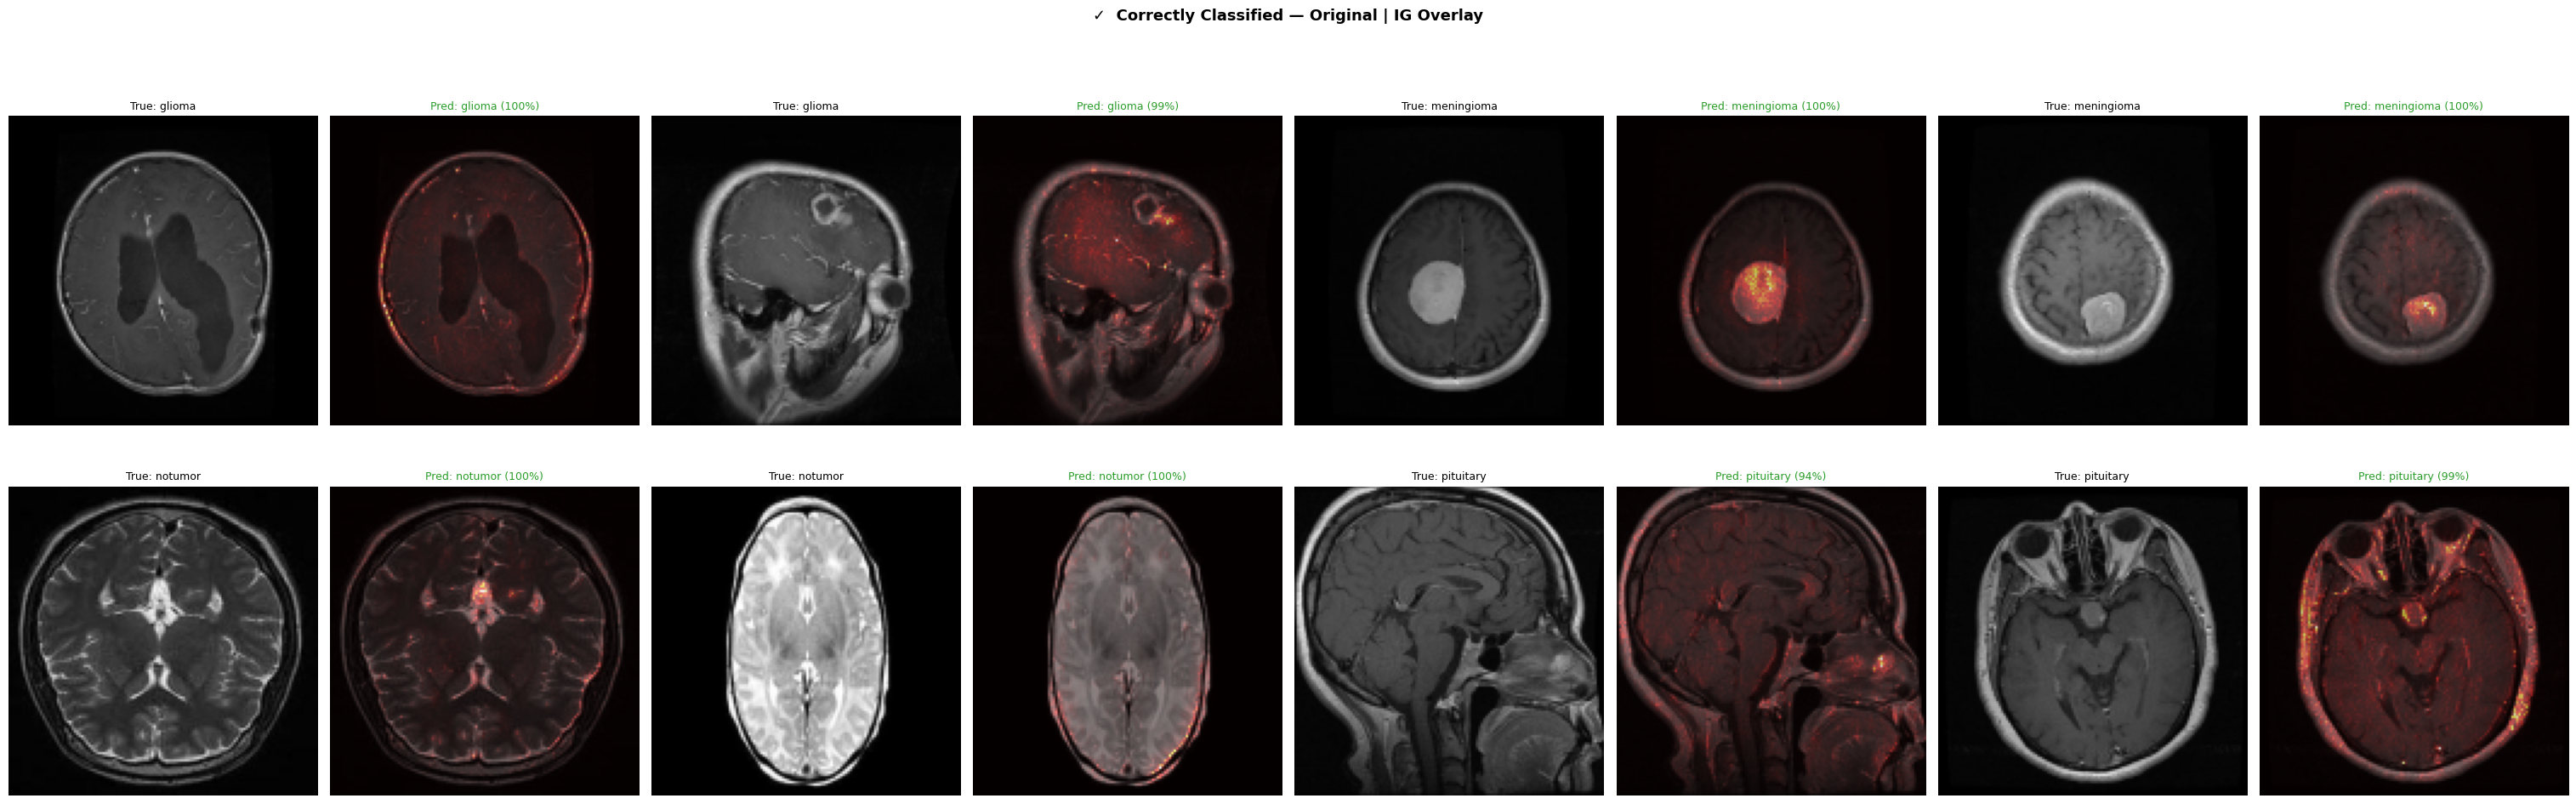


Plotting 8 misclassified samples...


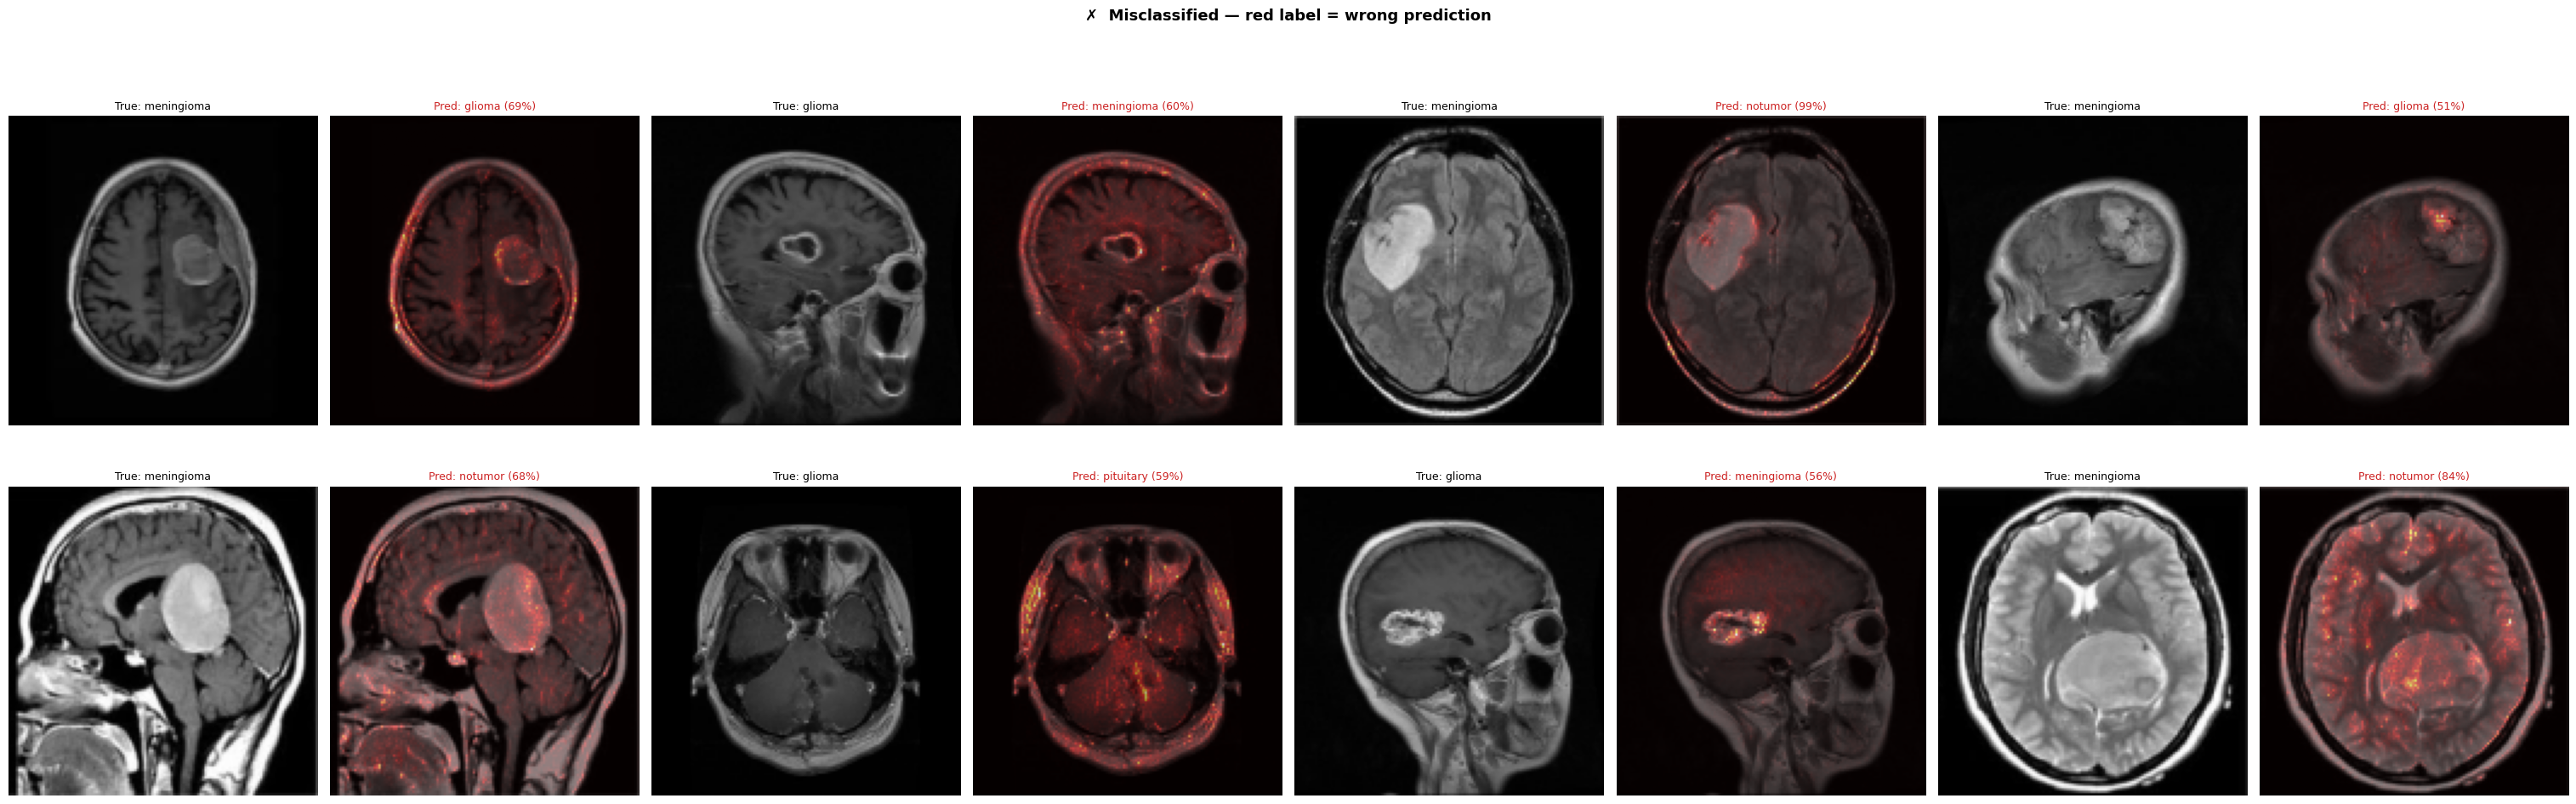

In [37]:
correct_indices = []
for cls_idx in range(len(CLASS_NAMES)):
    pool = np.where(correct_mask & (y_true_all == cls_idx))[0]
    if len(pool) >= 2:
        correct_indices.extend(np.random.choice(pool, 2, replace=False))

print(f"\nPlotting {len(correct_indices)} correctly classified samples...")
plot_ig_grid(correct_indices, "✓  Correctly Classified — Original | IG Overlay", n_cols=4)

# ── Visualize misclassified samples ───────────────────────────────────────────
mis_indices = np.where(misclassified_mask)[0]
np.random.shuffle(mis_indices)
n_show = min(8, len(mis_indices))

print(f"\nPlotting {n_show} misclassified samples...")
plot_ig_grid(
    mis_indices[:n_show],
    "✗  Misclassified — red label = wrong prediction",
    n_cols=4
)


# 14. Website

In [26]:
!pip install -q flask flask-cors pyngrok

In [27]:
# Then set your free ngrok token (get one at dashboard.ngrok.com):
from pyngrok import ngrok
ngrok.set_auth_token("3E1eMCqXb8tvvgva1wCJr0nbWBe_6bcAJQkUuD4DDKwaGoqJr")

In [28]:
HTML_PAGE = """<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8"/>
  <meta name="viewport" content="width=device-width, initial-scale=1.0"/>
  <title>NeuroScan</title>
  <link href="https://fonts.googleapis.com/css2?family=Space+Mono:wght@400;700&family=DM+Sans:ital,wght@0,300;0,400;0,500;1,300&display=swap" rel="stylesheet"/>
  <style>
    *, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0; }
    :root {
      --bg:      #060910;
      --surface: #0d1520;
      --border:  #1a2535;
      --accent:  #00d4ff;
      --accent2: #7b61ff;
      --text:    #e2e8f0;
      --muted:   #4a6080;
      --success: #00e5a0;
      --warn:    #ffb800;
      --mono:    'Space Mono', monospace;
      --sans:    'DM Sans', sans-serif;
    }
    body {
      font-family: var(--sans);
      background: var(--bg);
      color: var(--text);
      min-height: 100vh;
      display: flex;
      flex-direction: column;
      align-items: center;
      padding: 48px 20px 80px;
      background-image:
        linear-gradient(rgba(0,212,255,0.025) 1px, transparent 1px),
        linear-gradient(90deg, rgba(0,212,255,0.025) 1px, transparent 1px);
      background-size: 40px 40px;
    }

    header { text-align: center; margin-bottom: 52px; }
    .logo  {
      display: inline-flex; align-items: center; gap: 10px;
      margin-bottom: 10px;
    }
    .logo-pulse {
      width: 9px; height: 9px; border-radius: 50%;
      background: var(--accent);
      box-shadow: 0 0 10px var(--accent);
      animation: pulse 2.2s ease-in-out infinite;
    }
    @keyframes pulse {
      0%,100% { opacity:1; transform:scale(1); }
      50%      { opacity:.4; transform:scale(.7); }
    }
    h1 {
      font-family: var(--mono);
      font-size: clamp(1.7rem, 4vw, 2.5rem);
      letter-spacing: -.5px;
    }
    h1 span { color: var(--accent); }
    header p { font-size: .88rem; color: var(--muted); margin-top: 8px; font-weight: 300; }

    .wrap { width: 100%; max-width: 760px; }

    .card {
      background: var(--surface);
      border: 1px solid var(--border);
      border-radius: 16px;
      padding: 32px;
      margin-bottom: 20px;
      position: relative;
      overflow: hidden;
    }
    .card::before {
      content:''; position:absolute; top:0; left:0; right:0; height:1px;
      background: linear-gradient(90deg, transparent, var(--accent), transparent);
      opacity:.35;
    }

    /* ── Drop zone ── */
    #drop-zone {
      border: 1.5px dashed var(--border);
      border-radius: 12px;
      padding: 52px 24px;
      text-align: center;
      cursor: pointer;
      transition: border-color .2s, background .2s;
    }
    #drop-zone.over { border-color: var(--accent); background: rgba(0,212,255,.04); }
    #drop-zone svg  { margin-bottom: 14px; }
    .dz-title { font-family: var(--mono); font-size: .88rem; margin-bottom: 6px; }
    .dz-sub   { font-size: .78rem; color: var(--muted); }
    .dz-sub span { color: var(--accent); text-decoration: underline; cursor: pointer; text-underline-offset: 3px; }
    #file-input { display: none; }

    /* ── Preview ── */
    #preview-row {
      display: none; align-items: center; gap: 16px;
      margin-top: 18px; padding: 14px 16px;
      background: rgba(0,212,255,.04);
      border: 1px solid var(--border); border-radius: 10px;
    }
    #preview-img { width:72px; height:72px; object-fit:cover; border-radius:8px; border:1px solid var(--border); }
    #preview-name { font-family:var(--mono); font-size:.82rem; }
    #preview-size { font-size:.72rem; color:var(--muted); margin-top:4px; }

    /* ── Button ── */
    #analyze-btn {
      display: none; width: 100%; margin-top: 18px; padding: 14px;
      background: linear-gradient(135deg, var(--accent), var(--accent2));
      color: #000; border: none; border-radius: 10px;
      font-family: var(--mono); font-size: .88rem; font-weight: 700;
      letter-spacing: .06em; cursor: pointer;
      transition: opacity .2s, transform .1s;
    }
    #analyze-btn:hover:not(:disabled) { opacity:.88; transform:translateY(-1px); }
    #analyze-btn:disabled             { opacity:.4; cursor:not-allowed; }

    .spinner {
      display:inline-block; width:13px; height:13px;
      border:2px solid rgba(0,0,0,.25); border-top-color:#000;
      border-radius:50%; animation:spin .7s linear infinite;
      vertical-align:middle; margin-right:8px;
    }
    @keyframes spin { to { transform:rotate(360deg); } }

    #error-box {
      display:none; margin-top:12px; padding:11px 14px;
      background:rgba(255,77,109,.1); border:1px solid rgba(255,77,109,.3);
      border-radius:8px; color:#ff4d6d; font-family:var(--mono); font-size:.82rem;
    }

    /* ── Result ── */
    #result-card { display: none; }

    .res-class {
      font-family: var(--mono); font-size: 2rem; font-weight: 700;
      color: var(--accent); text-transform: uppercase; letter-spacing: .06em;
    }
    .res-conf  { font-family:var(--mono); font-size:.72rem; color:var(--muted); margin-top:5px; }
    .res-conf strong { color:var(--success); font-size:.95rem; }

    .res-desc {
      font-size:.87rem; color:var(--muted); line-height:1.75;
      padding:13px 15px; border-left:2px solid var(--accent2);
      background:rgba(123,97,255,.05); border-radius:0 8px 8px 0;
      margin:18px 0 24px;
    }

    .sec-label {
      font-family:var(--mono); font-size:.67rem;
      letter-spacing:.12em; color:var(--muted);
      text-transform:uppercase; margin-bottom:13px;
    }

    /* ── Prob bars ── */
    .prob-row { display:flex; align-items:center; gap:12px; margin-bottom:9px; }
    .prob-name { width:95px; font-family:var(--mono); font-size:.76rem; text-transform:capitalize; }
    .prob-track { flex:1; height:5px; background:var(--border); border-radius:3px; overflow:hidden; }
    .prob-fill  {
      height:100%; border-radius:3px; background:var(--muted);
      width:0%; transition:width .85s cubic-bezier(.16,1,.3,1);
    }
    .prob-fill.hi { background:linear-gradient(90deg,var(--accent2),var(--accent)); }
    .prob-pct { width:40px; text-align:right; font-family:var(--mono); font-size:.73rem; color:var(--muted); }

    /* ── IG panel ── */
    .ig-panel { margin-top:26px; }
    #overlay-img {
      display:none; width:100%; border-radius:10px;
      border:1px solid var(--border); margin-top:10px;
    }
    .ig-legend {
      display:flex; align-items:center; gap:8px;
      margin-top:10px; font-size:.76rem; color:var(--muted);
    }
    .ig-gradient {
      width:80px; height:8px; border-radius:4px;
      background:linear-gradient(90deg,#000,#f00,#ff0,#fff);
      flex-shrink:0;
    }

    /* ── Reset ── */
    #reset-btn {
      display:none; width:100%; margin-top:14px; padding:11px;
      background:transparent; color:var(--muted);
      border:1px solid var(--border); border-radius:10px;
      font-family:var(--mono); font-size:.78rem; cursor:pointer;
      transition:border-color .2s,color .2s;
    }
    #reset-btn:hover { border-color:var(--accent); color:var(--accent); }

    footer {
      margin-top:44px; font-family:var(--mono); font-size:.67rem;
      color:var(--muted); text-align:center; letter-spacing:.07em;
    }
  </style>
</head>
<body>

<header>
  <div class="logo">
    <div class="logo-pulse"></div>
    <h1>Neuro<span>Scan</span></h1>
    <div class="logo-pulse"></div>
  </div>
  <p>Upload a brain MRI &mdash; get classification + integrated gradients explanation</p>
</header>

<div class="wrap">

  <!-- upload -->
  <div class="card">
    <div id="drop-zone">
      <svg width="34" height="34" viewBox="0 0 24 24" fill="none"
           stroke="rgba(0,212,255,.45)" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round">
        <path d="M21 15v4a2 2 0 0 1-2 2H5a2 2 0 0 1-2-2v-4"/>
        <polyline points="17 8 12 3 7 8"/><line x1="12" y1="3" x2="12" y2="15"/>
      </svg>
      <p class="dz-title">Drop your MRI image here</p>
      <p class="dz-sub">or <span id="browse">browse files</span> &nbsp;&middot;&nbsp; JPG &middot; PNG &middot; BMP</p>
      <input type="file" id="file-input" accept="image/*"/>
    </div>
    <div id="preview-row">
      <img id="preview-img" alt="preview"/>
      <div><div id="preview-name"></div><div id="preview-size"></div></div>
    </div>
    <button id="analyze-btn">ANALYZE SCAN</button>
    <div id="error-box"></div>
  </div>

  <!-- result -->
  <div class="card" id="result-card">
    <div class="res-class" id="res-class">—</div>
    <div class="res-conf">CONFIDENCE &nbsp;<strong id="res-conf">—</strong></div>
    <div class="res-desc" id="res-desc">—</div>

    <div class="sec-label">Class probabilities</div>
    <div id="prob-bars"></div>

    <div class="ig-panel">
      <div class="sec-label">Integrated gradients — pixel attribution</div>
      <img id="overlay-img" alt="IG overlay"/>
      <div class="ig-legend">
        <div class="ig-gradient"></div>
        <span>dark = low attribution &nbsp;&rarr;&nbsp; white/yellow = high attribution (most influential pixels)</span>
      </div>
    </div>

    <button id="reset-btn">&#8592; ANALYZE ANOTHER SCAN</button>
  </div>

</div>
<footer>FOR RESEARCH &amp; EDUCATIONAL USE ONLY &nbsp;&middot;&nbsp; NOT A MEDICAL DIAGNOSTIC TOOL</footer>

<script>
const $  = id => document.getElementById(id);
const dz = $('drop-zone'), fi = $('file-input');
let file = null;

$('browse').onclick = () => fi.click();
dz.onclick = e => { if (e.target !== $('browse')) fi.click(); };
dz.addEventListener('dragover',  e => { e.preventDefault(); dz.classList.add('over'); });
dz.addEventListener('dragleave', ()  => dz.classList.remove('over'));
dz.addEventListener('drop',      e  => { e.preventDefault(); dz.classList.remove('over'); pick(e.dataTransfer.files[0]); });
fi.addEventListener('change',    ()  => pick(fi.files[0]));

function pick(f) {
  file = f;
  const r = new FileReader();
  r.onload = e => {
    $('preview-img').src = e.target.result;
    $('preview-name').textContent = f.name;
    $('preview-size').textContent = (f.size/1024).toFixed(1)+' KB';
    $('preview-row').style.display  = 'flex';
    $('analyze-btn').style.display  = 'block';
    $('error-box').style.display    = 'none';
    $('result-card').style.display  = 'none';
  };
  r.readAsDataURL(f);
}

$('analyze-btn').addEventListener('click', async () => {
  if (!file) return;
  const btn = $('analyze-btn');
  btn.disabled = true;
  btn.innerHTML = '<span class="spinner"></span>ANALYZING…';
  $('error-box').style.display = 'none';

  const fd = new FormData();
  fd.append('file', file);
  try {
    const res  = await fetch('/predict', { method:'POST', body:fd });
    const data = await res.json();
    if (!res.ok) throw new Error(data.error || 'Server error');
    render(data);
  } catch(e) {
    $('error-box').textContent = 'Error: ' + e.message;
    $('error-box').style.display = 'block';
  } finally {
    btn.disabled = false;
    btn.innerHTML = 'ANALYZE SCAN';
  }
});

function render(d) {
  $('res-class').textContent = d.prediction.toUpperCase();
  $('res-conf').textContent  = (d.confidence*100).toFixed(1)+'%';
  $('res-desc').textContent  = d.description;

  const bars = $('prob-bars');
  bars.innerHTML = '';
  Object.entries(d.probabilities)
    .sort((a,b) => b[1]-a[1])
    .forEach(([cls,p],i) => {
      const pct = (p*100).toFixed(1);
      bars.innerHTML += `
        <div class="prob-row">
          <span class="prob-name">${cls}</span>
          <div class="prob-track"><div class="prob-fill ${i===0?'hi':''}" data-w="${pct}%"></div></div>
          <span class="prob-pct">${pct}%</span>
        </div>`;
    });
  requestAnimationFrame(() => requestAnimationFrame(() => {
    document.querySelectorAll('.prob-fill').forEach(el => el.style.width = el.dataset.w);
  }));

  const oi = $('overlay-img');
  oi.src = 'data:image/png;base64,' + d.overlay_b64;
  oi.style.display = 'block';

  $('result-card').style.display = 'block';
  $('reset-btn').style.display   = 'block';
  $('result-card').scrollIntoView({ behavior:'smooth' });
}

$('reset-btn').addEventListener('click', () => {
  file = null; fi.value = '';
  ['preview-row','analyze-btn','result-card','reset-btn','error-box']
    .forEach(id => $id => $('${id}').style.display = 'none');
  // cleaner reset:
  $('preview-row').style.display  = 'none';
  $('analyze-btn').style.display  = 'none';
  $('result-card').style.display  = 'none';
  $('reset-btn').style.display    = 'none';
  $('error-box').style.display    = 'none';
  window.scrollTo({top:0, behavior:'smooth'});
});
</script>
</body>
</html>"""

In [29]:
# ── Helper: build the 3-panel overlay image as base64 PNG ─────
def build_overlay_b64(image, ig_map, display_size=(280, 280)):
    """
    Returns a base64 PNG string of a 3-panel figure:
    [Original MRI] [IG Heatmap] [Blended Overlay]
    Ready to embed directly in an HTML <img src="data:..."> tag.
    """
    # Resize everything to display_size for consistent output
    img_disp = cv2.resize(image, display_size, interpolation=cv2.INTER_AREA)
    ig_disp  = cv2.resize(ig_map, display_size, interpolation=cv2.INTER_LINEAR)

    orig_rgb  = cv2.cvtColor(img_disp, cv2.COLOR_BGR2RGB) / 255.0
    heatmap   = cm.hot(ig_disp)[:, :, :3]
    overlay   = np.clip(orig_rgb * 0.5 + heatmap * 0.5, 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.patch.set_facecolor('#0d1117')
    pairs = [('Original MRI', orig_rgb, 'gray'),
             ('Attribution map', ig_disp, 'hot'),
             ('Overlay', overlay, None)]

    for ax, (ttl, img, cmap) in zip(axes, pairs):
        ax.imshow(img, cmap=cmap)
        ax.set_title(ttl, color='white', fontsize=9, pad=7)
        ax.axis('off')

    plt.tight_layout(pad=1.5)
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=120, bbox_inches='tight',
                facecolor='#0d1117')
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode('utf-8')


In [30]:
# ── Flask app factory ──────────────────────────────────────────
def run_flask_app(model, class_names, class_info, img_size):
    """
    Starts Flask inside Colab and exposes it publicly via ngrok.

    Usage:
        url = run_flask_app(model, CLASS_NAMES, CLASS_INFO, IMG_SIZE)
    """
    from flask import Flask, request, jsonify, Response
    from flask_cors import CORS
    from pyngrok import ngrok

    app = Flask(__name__)
    CORS(app)

    @app.route('/')
    def index():
        return Response(HTML_PAGE, mimetype='text/html')

    @app.route('/predict', methods=['POST'])
    def predict():
        if 'file' not in request.files:
            return jsonify({'error': 'No file provided'}), 400

        file_bytes = np.frombuffer(request.files['file'].read(), np.uint8)
        img_bgr    = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
        if img_bgr is None:
            return jsonify({'error': 'Could not decode image'}), 400

        # Preprocess: resize to training size
        img = cv2.resize(img_bgr, img_size, interpolation=cv2.INTER_AREA)

        # Inference
        probs      = tf.nn.softmax(
            model(tf.cast(img[np.newaxis], tf.float32), training=False), axis=-1
        )[0].numpy()
        pred_class = int(np.argmax(probs))
        confidence = float(probs[pred_class])

        # Integrated Gradients + overlay
        ig_map      = compute_integrated_gradients(model, img, pred_class)
        overlay_b64 = build_overlay_b64(img, ig_map)

        return jsonify({
            'prediction':    class_names[pred_class],
            'confidence':    round(confidence, 4),
            'probabilities': {class_names[i]: round(float(probs[i]), 4)
                              for i in range(len(class_names))},
            'description':   class_info[class_names[pred_class]],
            'overlay_b64':   overlay_b64,
        })

    ngrok.kill()
    public_url = ngrok.connect(5000)
    print(f"\n{'━'*52}")
    print(f"  NeuroScan live at → {public_url}")
    print(f"  Open the URL above in any browser")
    print(f"  Ctrl+C in the cell output to stop")
    print(f"{'━'*52}\n")

    t = threading.Thread(
        target=lambda: app.run(host='0.0.0.0', port=5000, use_reloader=False)
    )
    t.daemon = True
    t.start()
    return public_url



In [31]:
# ── Launch the web app ─────────────────────────────────────────
# Make sure CLASS_INFO is defined. Add this dict in your notebook if not:

CLASS_INFO = {
    'glioma':     'Arises from glial cells. Ranges from slow-growing (grade I) to aggressive glioblastoma (grade IV).',
    'meningioma': 'Grows on the meninges (brain lining). Usually benign and slow-growing.',
    'notumor':    'No tumor detected in this scan.',
    'pituitary':  'Forms on the pituitary gland. Usually benign but can affect hormone levels.',
}


In [32]:
!pip install -q flask flask-cors pyngrok

In [33]:
from pyngrok import ngrok
ngrok.set_auth_token("3E1eMCqXb8tvvgva1wCJr0nbWBe_6bcAJQkUuD4DDKwaGoqJr")       # free at dashboard.ngrok.com
url = run_flask_app(model, CLASS_NAMES, CLASS_INFO, IMG_SIZE)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  NeuroScan live at → NgrokTunnel: "https://liable-peso-docile.ngrok-free.dev" -> "http://localhost:5000"
  Open the URL above in any browser
  Ctrl+C in the cell output to stop
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



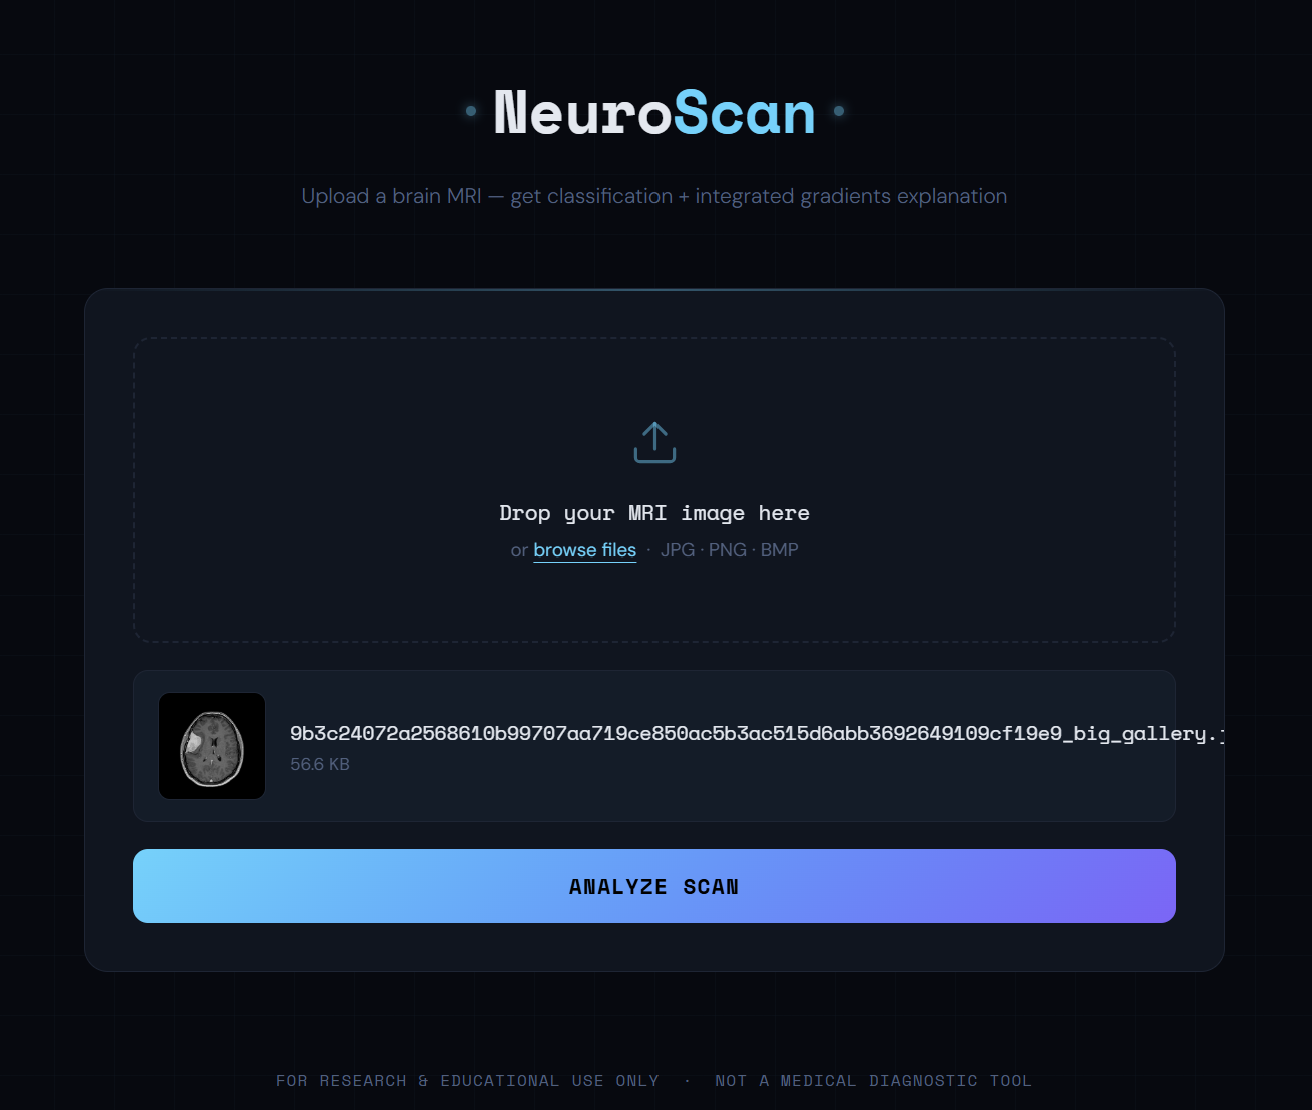

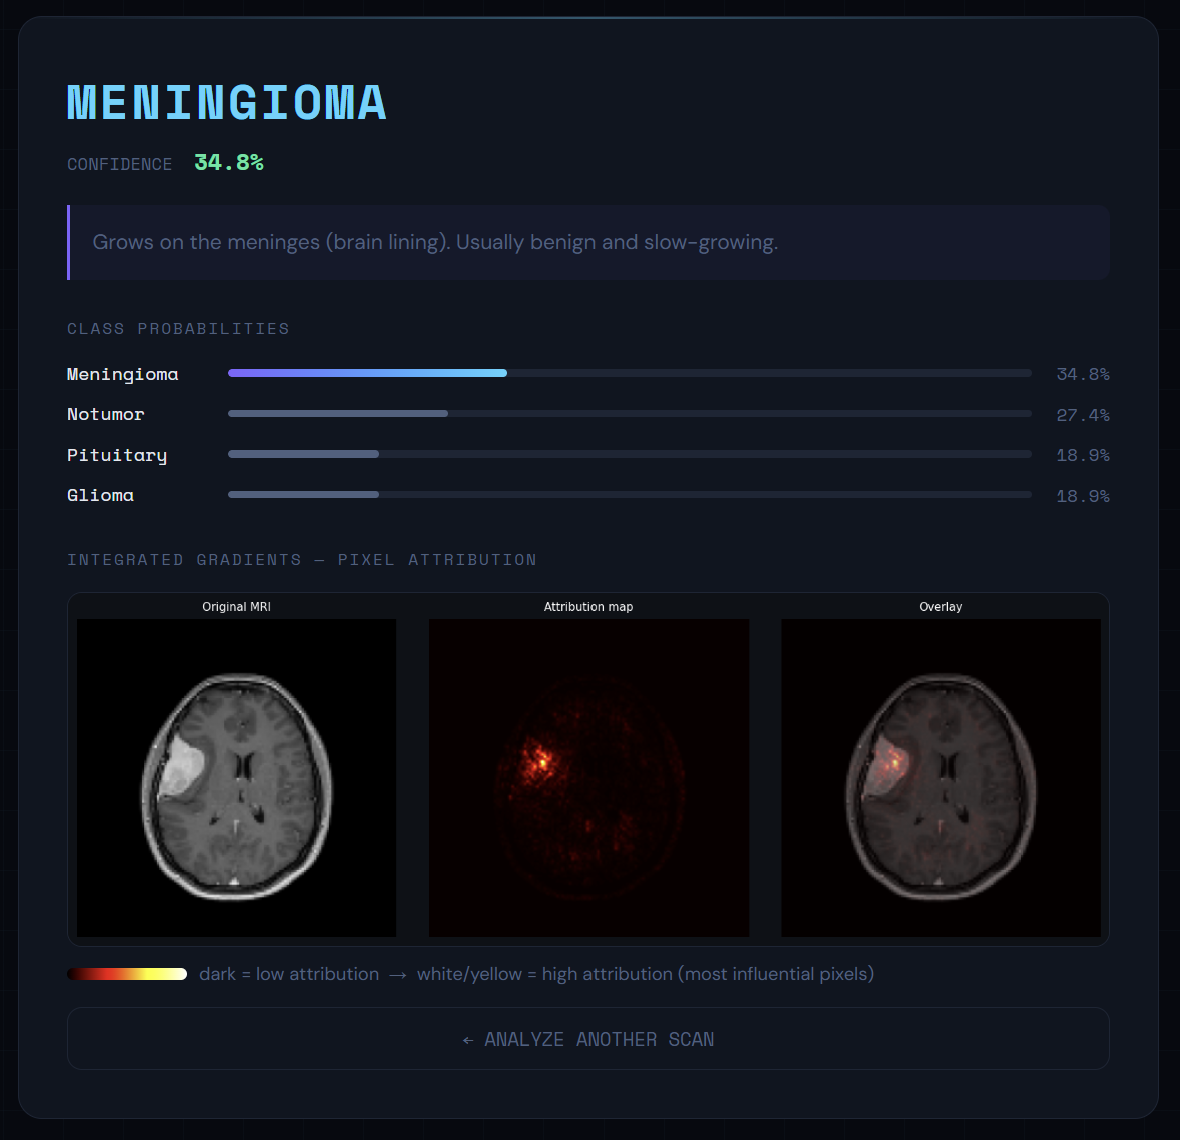